In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
train_df = pd.read_csv("../data/processed/train_processed.csv")
valid_df = pd.read_csv("../data/processed/valid_processed.csv")

print(train_df.shape)
print(valid_df.shape)

(9539, 3)
(2388, 3)


In [3]:
X_train = train_df["clean_text"]
X_valid = valid_df["clean_text"]

y_train = train_df["label"]
y_valid = valid_df["label"]

print(X_train.shape)
print(y_train.shape)

(9539,)
(9539,)


In [4]:
max_words = 10000
max_len = 25

tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_valid_seq = tokenizer.texts_to_sequences(X_valid)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_valid_pad = pad_sequences(X_valid_seq, maxlen=max_len)

print(X_train_pad.shape)
print(X_valid_pad.shape)

(9539, 25)
(2388, 25)


In [5]:
y_train_cat = to_categorical(y_train, num_classes=3)
y_valid_cat = to_categorical(y_valid, num_classes=3)

print(y_train_cat.shape)
print(y_valid_cat.shape)

(9539, 3)
(2388, 3)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, Bidirectional
from tensorflow.keras.layers import GRU

model = Sequential()

model.add(Embedding(
    input_dim=max_words,
    output_dim=64,
    input_shape=(max_len,)
))

model.add(Bidirectional(
    GRU(
        128,
        dropout=0.3,
        recurrent_dropout=0.3
    )
))


model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(3, activation="softmax"))

model.summary()

c:\Desktop copy\financial-news-sentiment-analysis\venv\lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 25, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       148,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 797,315 (3.04 MB)

 Trainable params: 797,315 (3.04 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [9]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_valid_pad, y_valid),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.6690 - loss: 0.8114 - val_accuracy: 0.7295 - val_loss: 0.6577
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.7651 - loss: 0.5555 - val_accuracy: 0.7580 - val_loss: 0.5873
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.8474 - loss: 0.3950 - val_accuracy: 0.7919 - val_loss: 0.5577
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.9045 - loss: 0.2626 - val_accuracy: 0.7864 - val_loss: 0.6003
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9328 - loss: 0.2020 - val_accuracy: 0.7814 - val_loss: 0.6783


In [10]:
val_loss, val_acc = model.evaluate(X_valid_pad, y_valid)

print("Validation Accuracy:", val_acc)
print("Validation Loss:", val_loss)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7919 - loss: 0.5577
Validation Accuracy: 0.7918760180473328
Validation Loss: 0.557692289352417


In [11]:
y_pred = model.predict(X_valid_pad)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [12]:
import numpy as np

y_pred_classes = np.argmax(y_pred, axis=1)

In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, y_pred_classes))

              precision    recall  f1-score   support

           0       0.66      0.50      0.57       347
           1       0.66      0.68      0.67       475
           2       0.85      0.89      0.87      1566

    accuracy                           0.79      2388
   macro avg       0.72      0.69      0.70      2388
weighted avg       0.79      0.79      0.79      2388



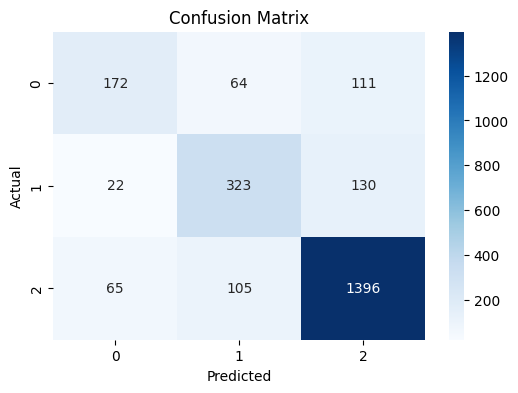

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_pred_classes)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [15]:
model.save("../models/rnn/rnn_model.keras")

In [16]:
import pickle

with open("../models/tokenizer/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [17]:
def predict_sentiment(text):

    seq = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(seq, maxlen=max_len)

    pred = model.predict(padded)

    label = np.argmax(pred)

    confidence = np.max(pred)

    sentiment = {
        0: "Bearish",
        1: "Neutral",
        2: "Bullish"
    }

    return sentiment[label], confidence

In [18]:
predict_sentiment("The company reported strong quarterly profits")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


('Neutral', np.float32(0.7858954))